# Functional API and Non-Sequential Network Foundations

This notebook develops the architectural ideas that motivate graph-based neural networks. It starts from the limitations of strictly sequential models and progresses through the Keras Functional API, directed acyclic graphs, parallel branches, Inception-style processing, skip connections, and common graph-construction errors.

MNIST is used for the executable examples so that the focus stays on architecture rather than training cost.


A strictly the Sequential model in Keras, which allows to build a large variety of models.

However, the sequential model does not allow building networks with:

* Multiple inputs.

* Multiple outputs.

* Parallel branches.


In the functional API, you directly manipulate tensors, and you use layers as functions
that take tensors and return tensors (hence, the name functional API).


## **Limitations of the Sequential Model:**


For example, consider a question-answering model.

A typical question-answering model has two inputs: a natural-language question
and a text snippet (such as a news article) providing information to be used for
answering the question. The model must then produce an answer: in the simplest possible setup, this is a one-word answer obtained via a softmax over some predefined vocabulary.


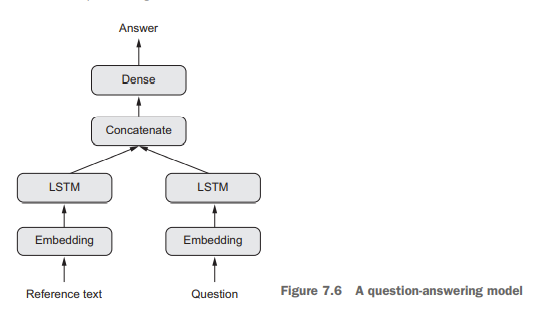


The inception module allows us to process an image using convolutional filters of different sizes in parallel:


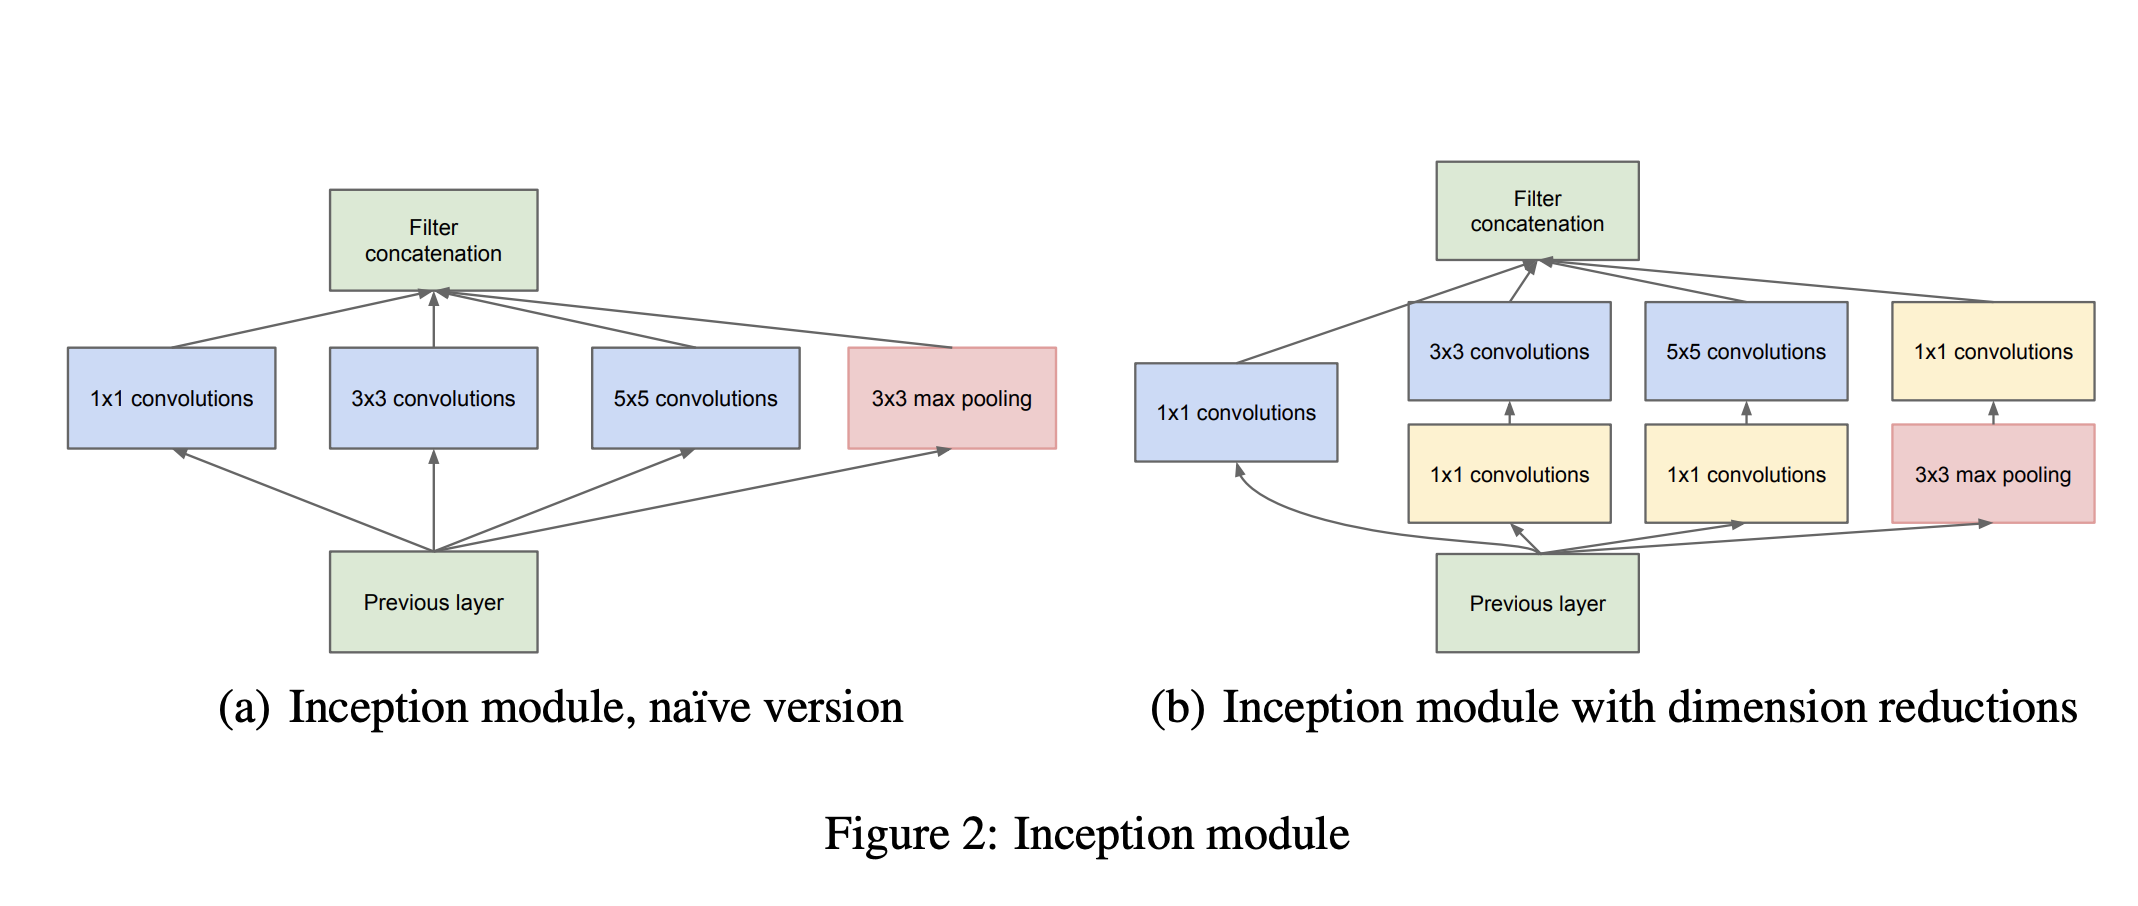


A residual network allows layers that receive inputs not just from the previous layer, but from any earlier layer.


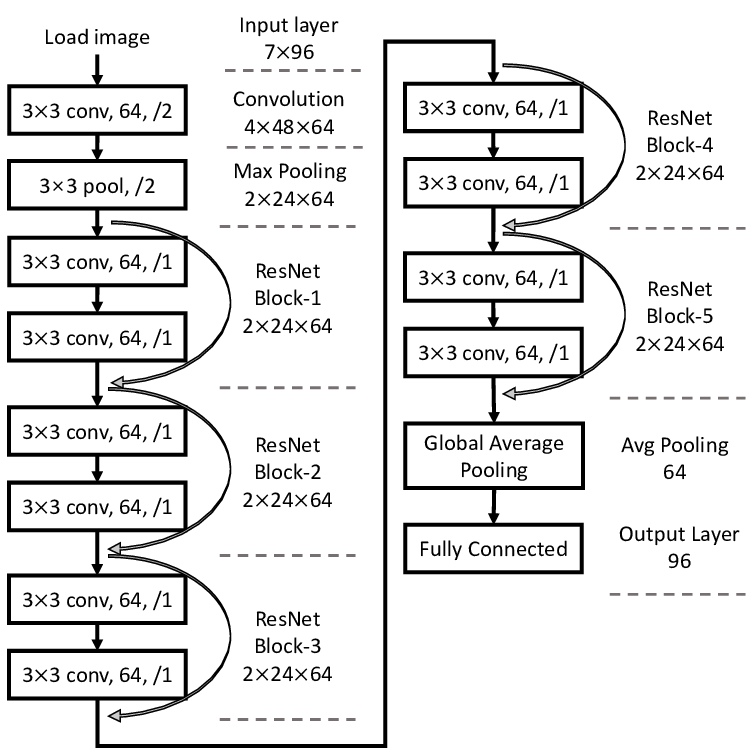


A Unet architecture allows to compute image-to-image transformations.


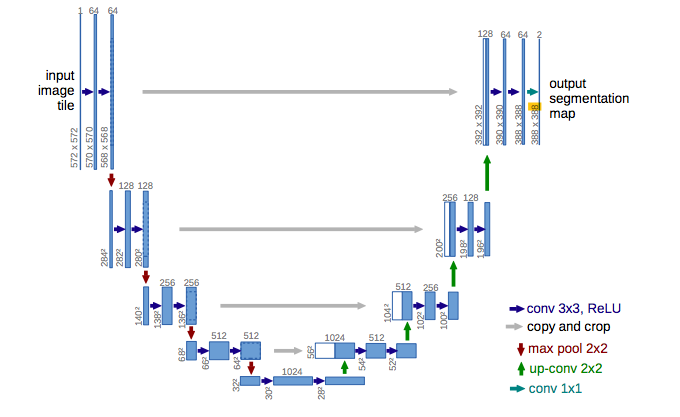


## MNIST Setup


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from tensorflow.keras.utils import plot_model

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# add empty color dimension and scale to [0,1]
x_train = np.float32(np.expand_dims(x_train, -1)/255)
x_test = np.float32(np.expand_dims(x_test, -1)/255)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def plot_results(all_history):
  loss, val_loss, accuracy, val_accuracy = [], [], [], []
  for history in all_history:
    loss += history.history['loss']
    val_loss += history.history['val_loss']
    accuracy += history.history['accuracy']
    val_accuracy += history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')


## Sequential CNN Reference


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,306 (1.66 MB)

 Trainable params: 435,306 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

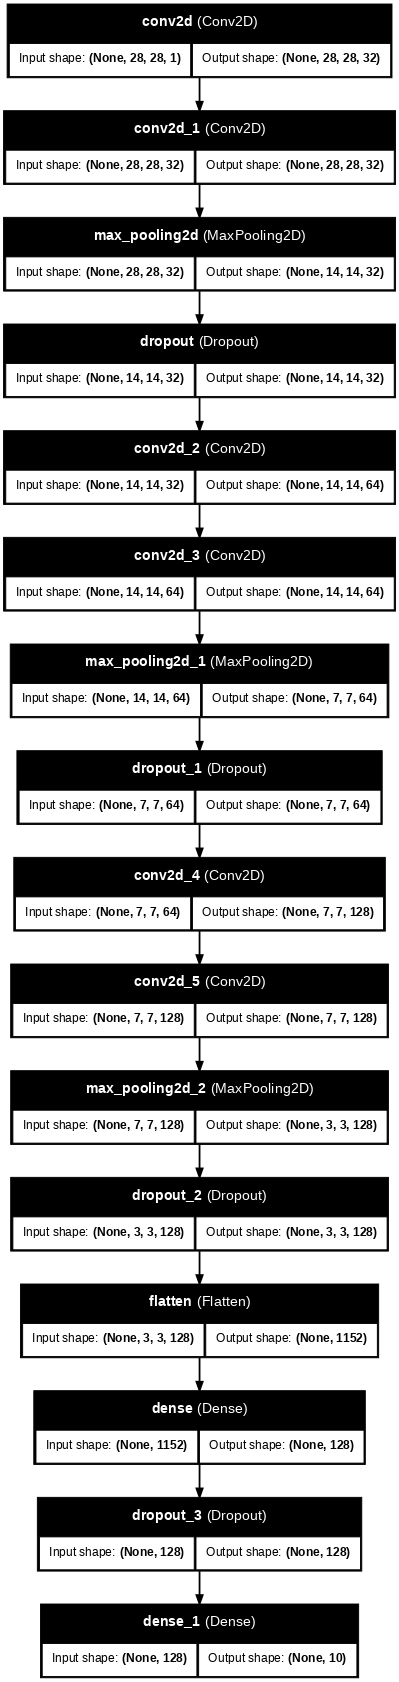

In [4]:
def cnn_model(input_shape=(28,28,1)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), input_shape=input_shape,  padding='same', activation="relu"))
  model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.2))
  model.add(Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.2))
  model.add(Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.2))
  model.add(Flatten())
  model.add(Dense(128, activation='relu'))
  model.add(Dropout(0.2))
  model.add(Dense(10, activation='softmax'))
  return model

cnn = cnn_model()
cnn.summary()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True, dpi=64)


In [5]:
cnn = cnn_model()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8727 - loss: 0.3961 - val_accuracy: 0.9305 - val_loss: 0.2086
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9765 - loss: 0.0750 - val_accuracy: 0.9841 - val_loss: 0.0457
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9848 - loss: 0.0488 - val_accuracy: 0.9846 - val_loss: 0.0533
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - loss: 0.0398 - val_accuracy: 0.9927 - val_loss: 0.0239
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0302 - val_accuracy: 0.9939 - val_loss: 0.0201
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9920 - loss: 0.0260 - val_accuracy: 0.9924 - val_loss: 0.0255
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9928 - loss: 0.0224 - val_accuracy: 0.9950 - val_loss: 0.0169
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9940 - loss: 0.0203 - val_accuracy: 

## Equivalent Functional API CNN


In [6]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


In [7]:
cnn = cnn_model_api()
cnn.summary()


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,306 (1.66 MB)

 Trainable params: 435,306 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

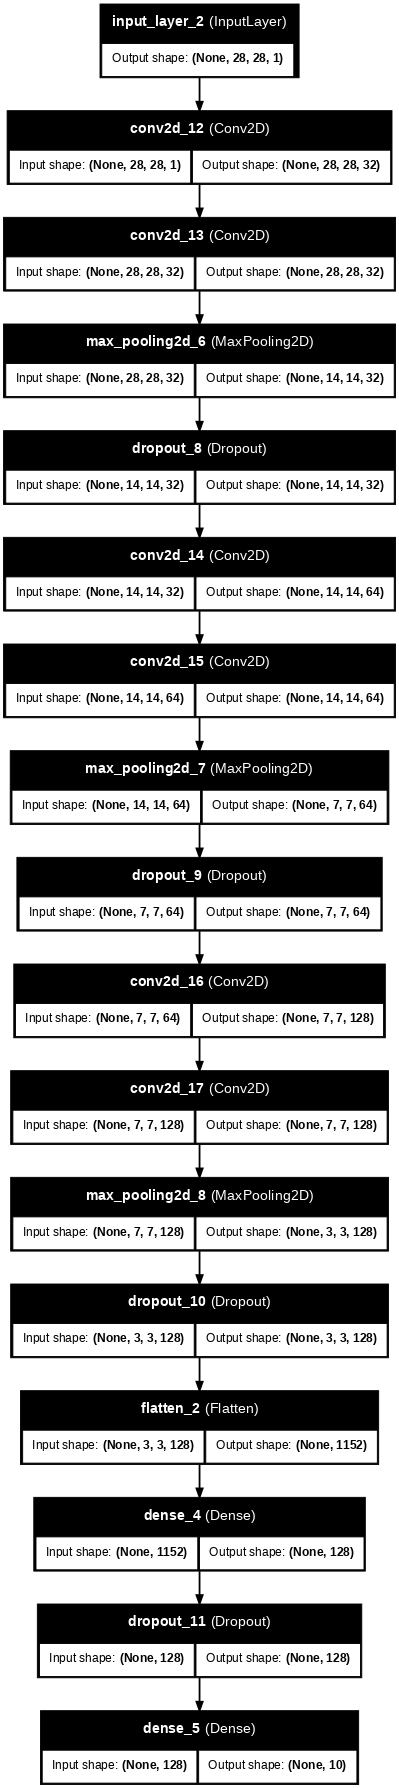

In [8]:
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True, dpi=64)


In [9]:
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8718 - loss: 0.3998 - val_accuracy: 0.9752 - val_loss: 0.0780
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9783 - loss: 0.0716 - val_accuracy: 0.9839 - val_loss: 0.0480
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.9905 - val_loss: 0.0279
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9889 - loss: 0.0368 - val_accuracy: 0.9927 - val_loss: 0.0216
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9906 - loss: 0.0301 - val_accuracy: 0.9946 - val_loss: 0.0192
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9924 - loss: 0.0247 - val_accuracy: 0.9929 - val_loss: 0.0191
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9934 - loss: 0.0216 - val_accuracy: 0.9941 - val_loss: 0.0183
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9944 - loss: 0.0185 - val_accuracy: 

## Directed Acyclic Graphs and Parallel Branches


In [10]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch3)
  concatanated = Concatenate()([branch1,branch2,branch3])
  net = MaxPooling2D(pool_size=(2, 2))(concatanated)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


### Alternate Parallel-Branch Topology


In [11]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch2)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch3)
  branch4 = MaxPooling2D(pool_size=(3, 3), padding='same', strides=1)(inputs)
  branch4 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(branch4)
  concatenated = Concatenate()([branch1,branch2,branch3,branch4])
  concatenated = MaxPooling2D(pool_size=(2, 2))(concatenated)
  net = Flatten()(concatenated)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 28, 28,    │         64 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 28, 28,    │         64 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 28, 28,    │         64 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 28, 28, 1) │          0 │ input_layer_3[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_18[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 28, 28,    │     25,632 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_22[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 28, 28,    │         64 │ max_pooling2d_9[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28,    │          0 │ conv2d_19[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_21[0][0],  │
│                     │                   │            │ conv2d_23[0][0],  │
│                     │                   │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 14, 14,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      1,290 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,257,066 (12.42 MB)

 Trainable params: 3,257,066 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

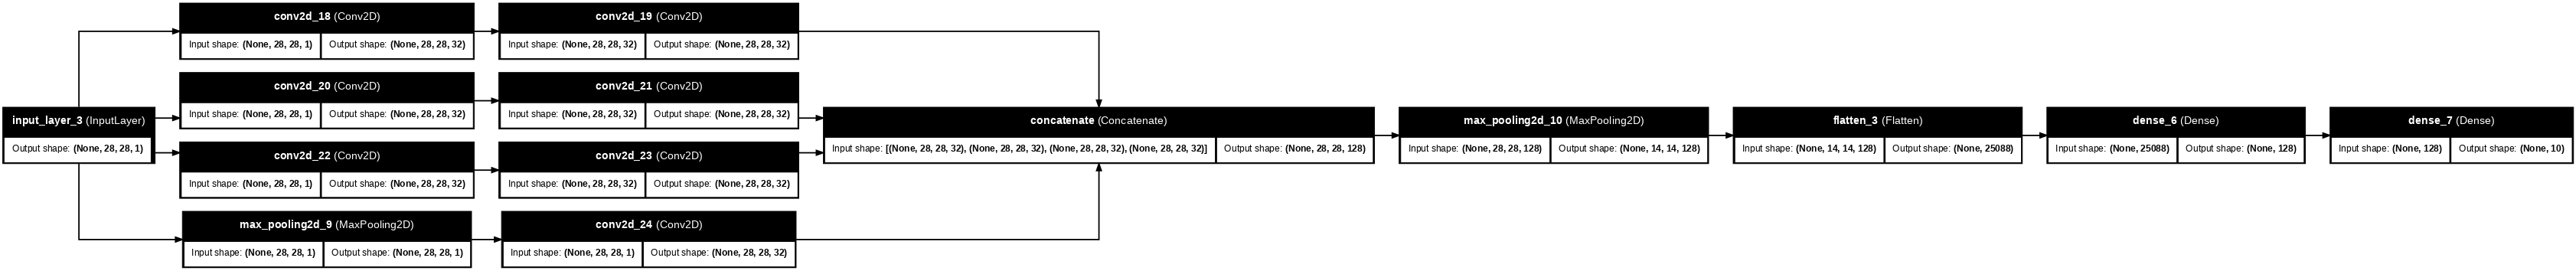

In [12]:
cnn = cnn_model_api()
cnn.summary()
plot_model(cnn, rankdir="LR", to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


In [13]:
cnn = cnn_model_api()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9206 - loss: 0.2562 - val_accuracy: 0.9740 - val_loss: 0.0805
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9828 - loss: 0.0561 - val_accuracy: 0.9857 - val_loss: 0.0437
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9891 - loss: 0.0360 - val_accuracy: 0.9879 - val_loss: 0.0348
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9897 - val_loss: 0.0311
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9948 - loss: 0.0167 - val_accuracy: 0.9893 - val_loss: 0.0313
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.9883 - val_loss: 0.0396
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9971 - loss: 0.0087 - val_accuracy: 0.9902 - val_loss: 0.0354
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 

### Reusable Inception-Style Block


In [14]:
def inception_block(input):
  branch1 = Conv2D(16, kernel_size=(1, 1),activation='relu', padding='same')(input)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(16, kernel_size=(1, 1),activation='relu', padding='same')(input)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch2)
  branch3 = Conv2D(16, kernel_size=(1, 1),activation='relu', padding='same')(input)
  branch3 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch3)
  branch4 = MaxPooling2D(pool_size=(3, 3), padding='same', strides=1)(input)
  branch4 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(branch4)
  return Concatenate()([branch1,branch2,branch3,branch4])

def incep2(input_shape=(28,28,1)):
  input = Input(shape=input_shape)
  net = input
  for i in range(2):
    net = inception_block(net)
    net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  output = Dense(10, activation='softmax')(net)
  model = Model(inputs=input, outputs=output, name='classification_model')
  return model


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 28, 28,    │         32 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 28, 28,    │         32 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 28, 28,    │         32 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 28, 28, 1) │          0 │ input_layer_5[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 28, 28,    │      4,640 │ conv2d_32[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_34[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 28, 28,    │      4,640 │ conv2d_36[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 28, 28,    │         64 │ max_pooling2d_13… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 28, 28,    │          0 │ conv2d_33[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_35[0][0],  │
│                     │                   │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 14, 14,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 14, 14,    │      2,064 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 14, 14,    │      2,064 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 14, 14,    │      2,064 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 14, 14,    │          0 │ max_pooling2d_14… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 14, 14,    │      4,640 │ conv2d_39[0][0]   │
│                     │ 32)               │            │                 

 Total params: 858,938 (3.28 MB)

 Trainable params: 858,938 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

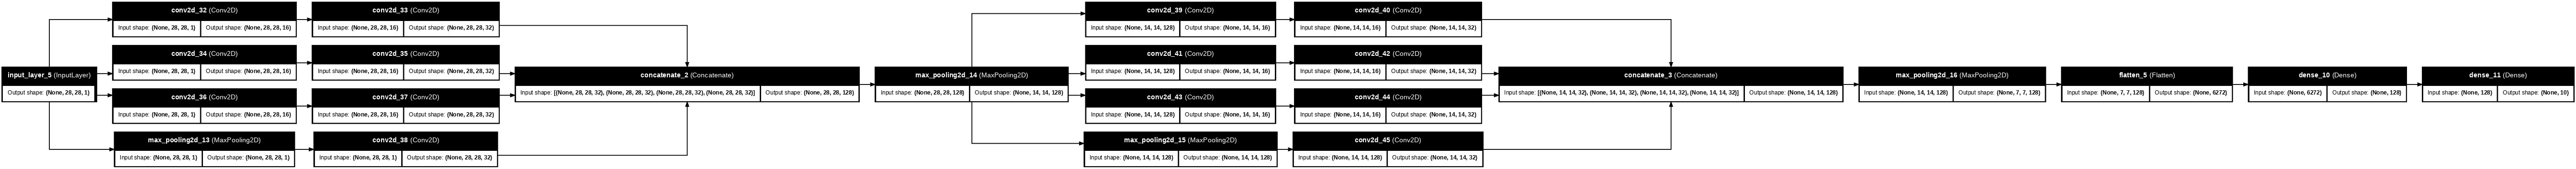

In [15]:
cnn = incep2()
cnn.summary()
plot_model(cnn, rankdir="LR", to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


In [16]:
cnn = cnn = incep2()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9230 - loss: 0.2477 - val_accuracy: 0.9775 - val_loss: 0.0713
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9853 - loss: 0.0478 - val_accuracy: 0.9892 - val_loss: 0.0416
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9899 - loss: 0.0311 - val_accuracy: 0.9748 - val_loss: 0.0757
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9948 - loss: 0.0161 - val_accuracy: 0.9875 - val_loss: 0.0389
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9963 - loss: 0.0121 - val_accuracy: 0.9924 - val_loss: 0.0246
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9971 - loss: 0.0090 - val_accuracy: 0.9908 - val_loss: 0.0398
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9975 - loss: 0.0081 - val_accuracy: 

### Additional Parallel-Branch CNN


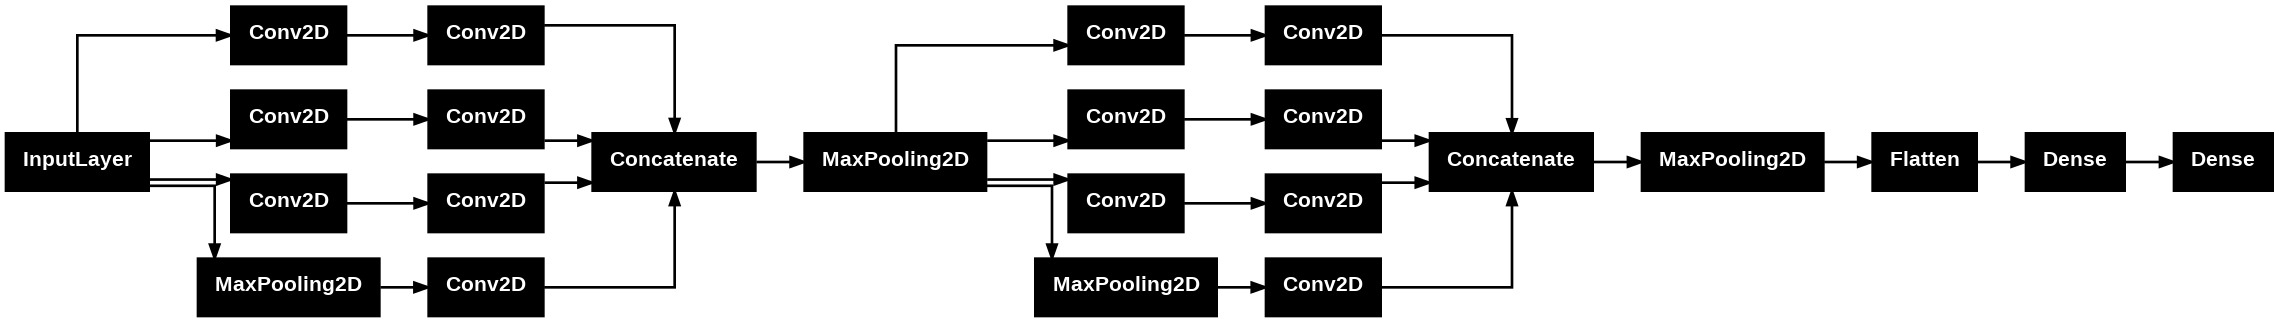

In [17]:
plot_model(cnn, rankdir="LR", dpi=96)


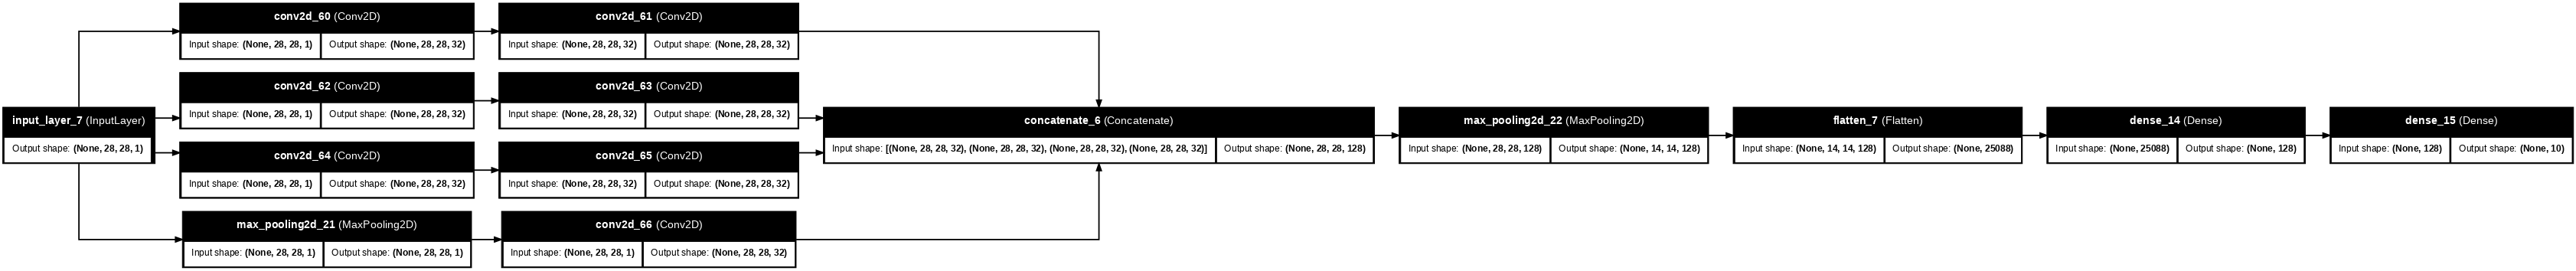

In [18]:
cnn = cnn_model_api()
#cnn.summary()
plot_model(cnn, rankdir="LR", to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


## Skip Connections


In [19]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


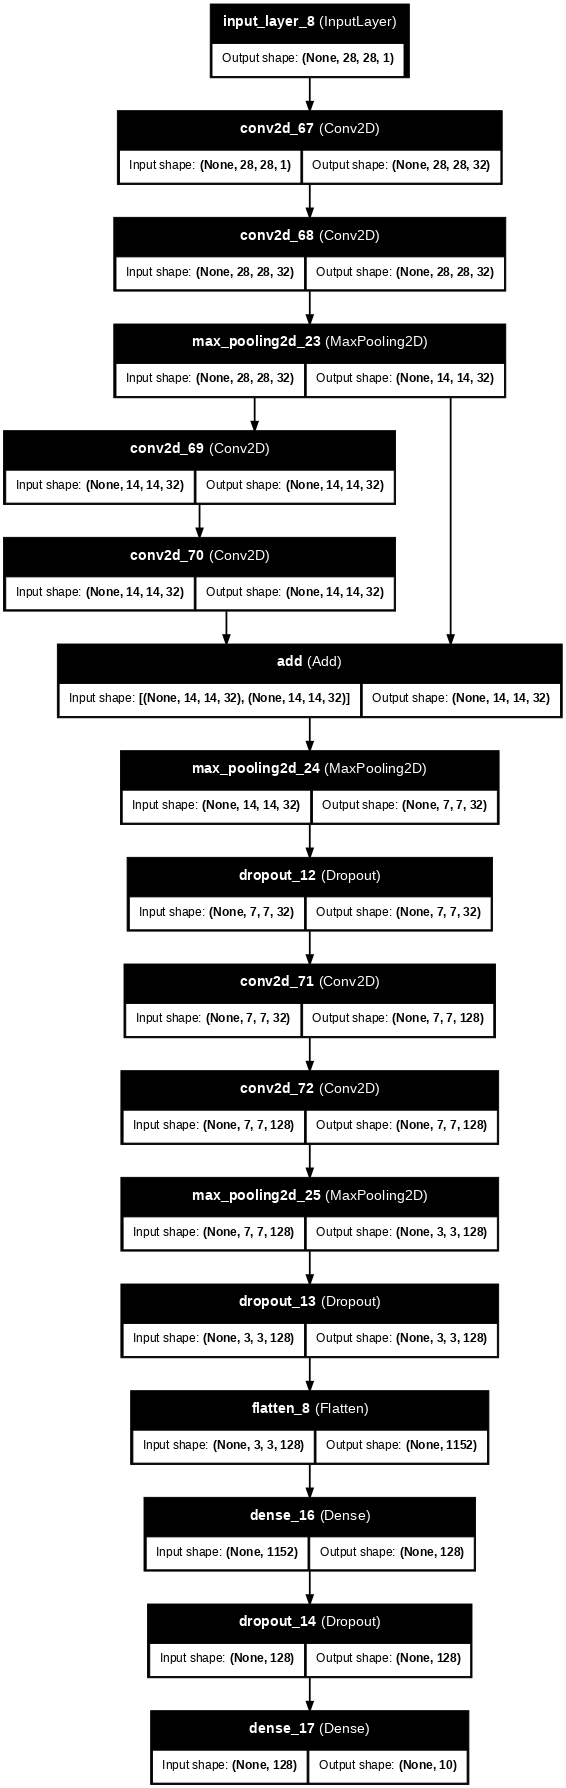

In [20]:
cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


## Common Functional-Graph Construction Errors


### Unused Layer


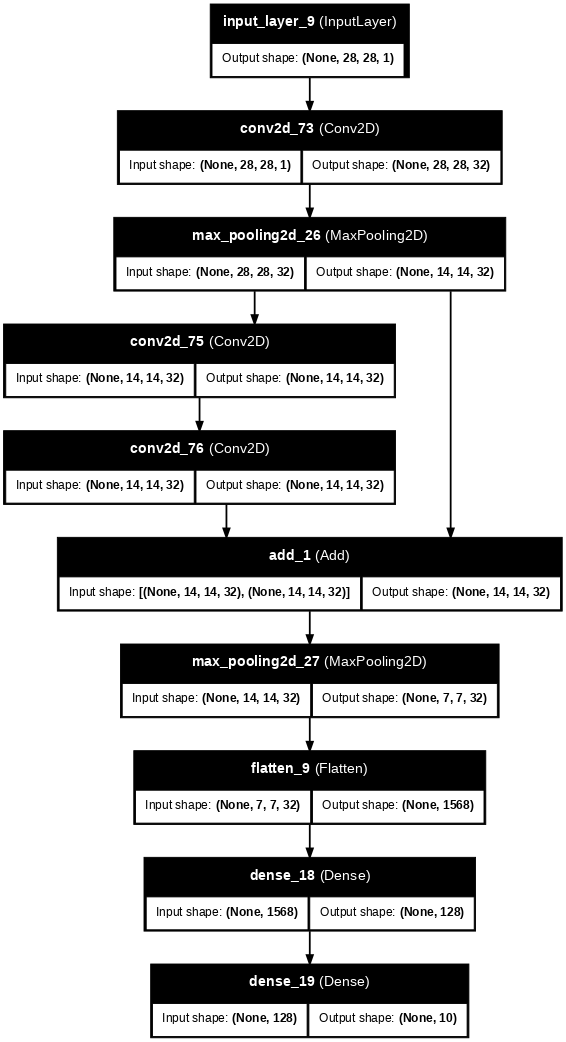

In [21]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  useless = Conv2D(256, kernel_size=(3, 3),activation='relu', padding='same')(net) # This node is not connected to anything
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


### Incompatible Tensor Shapes


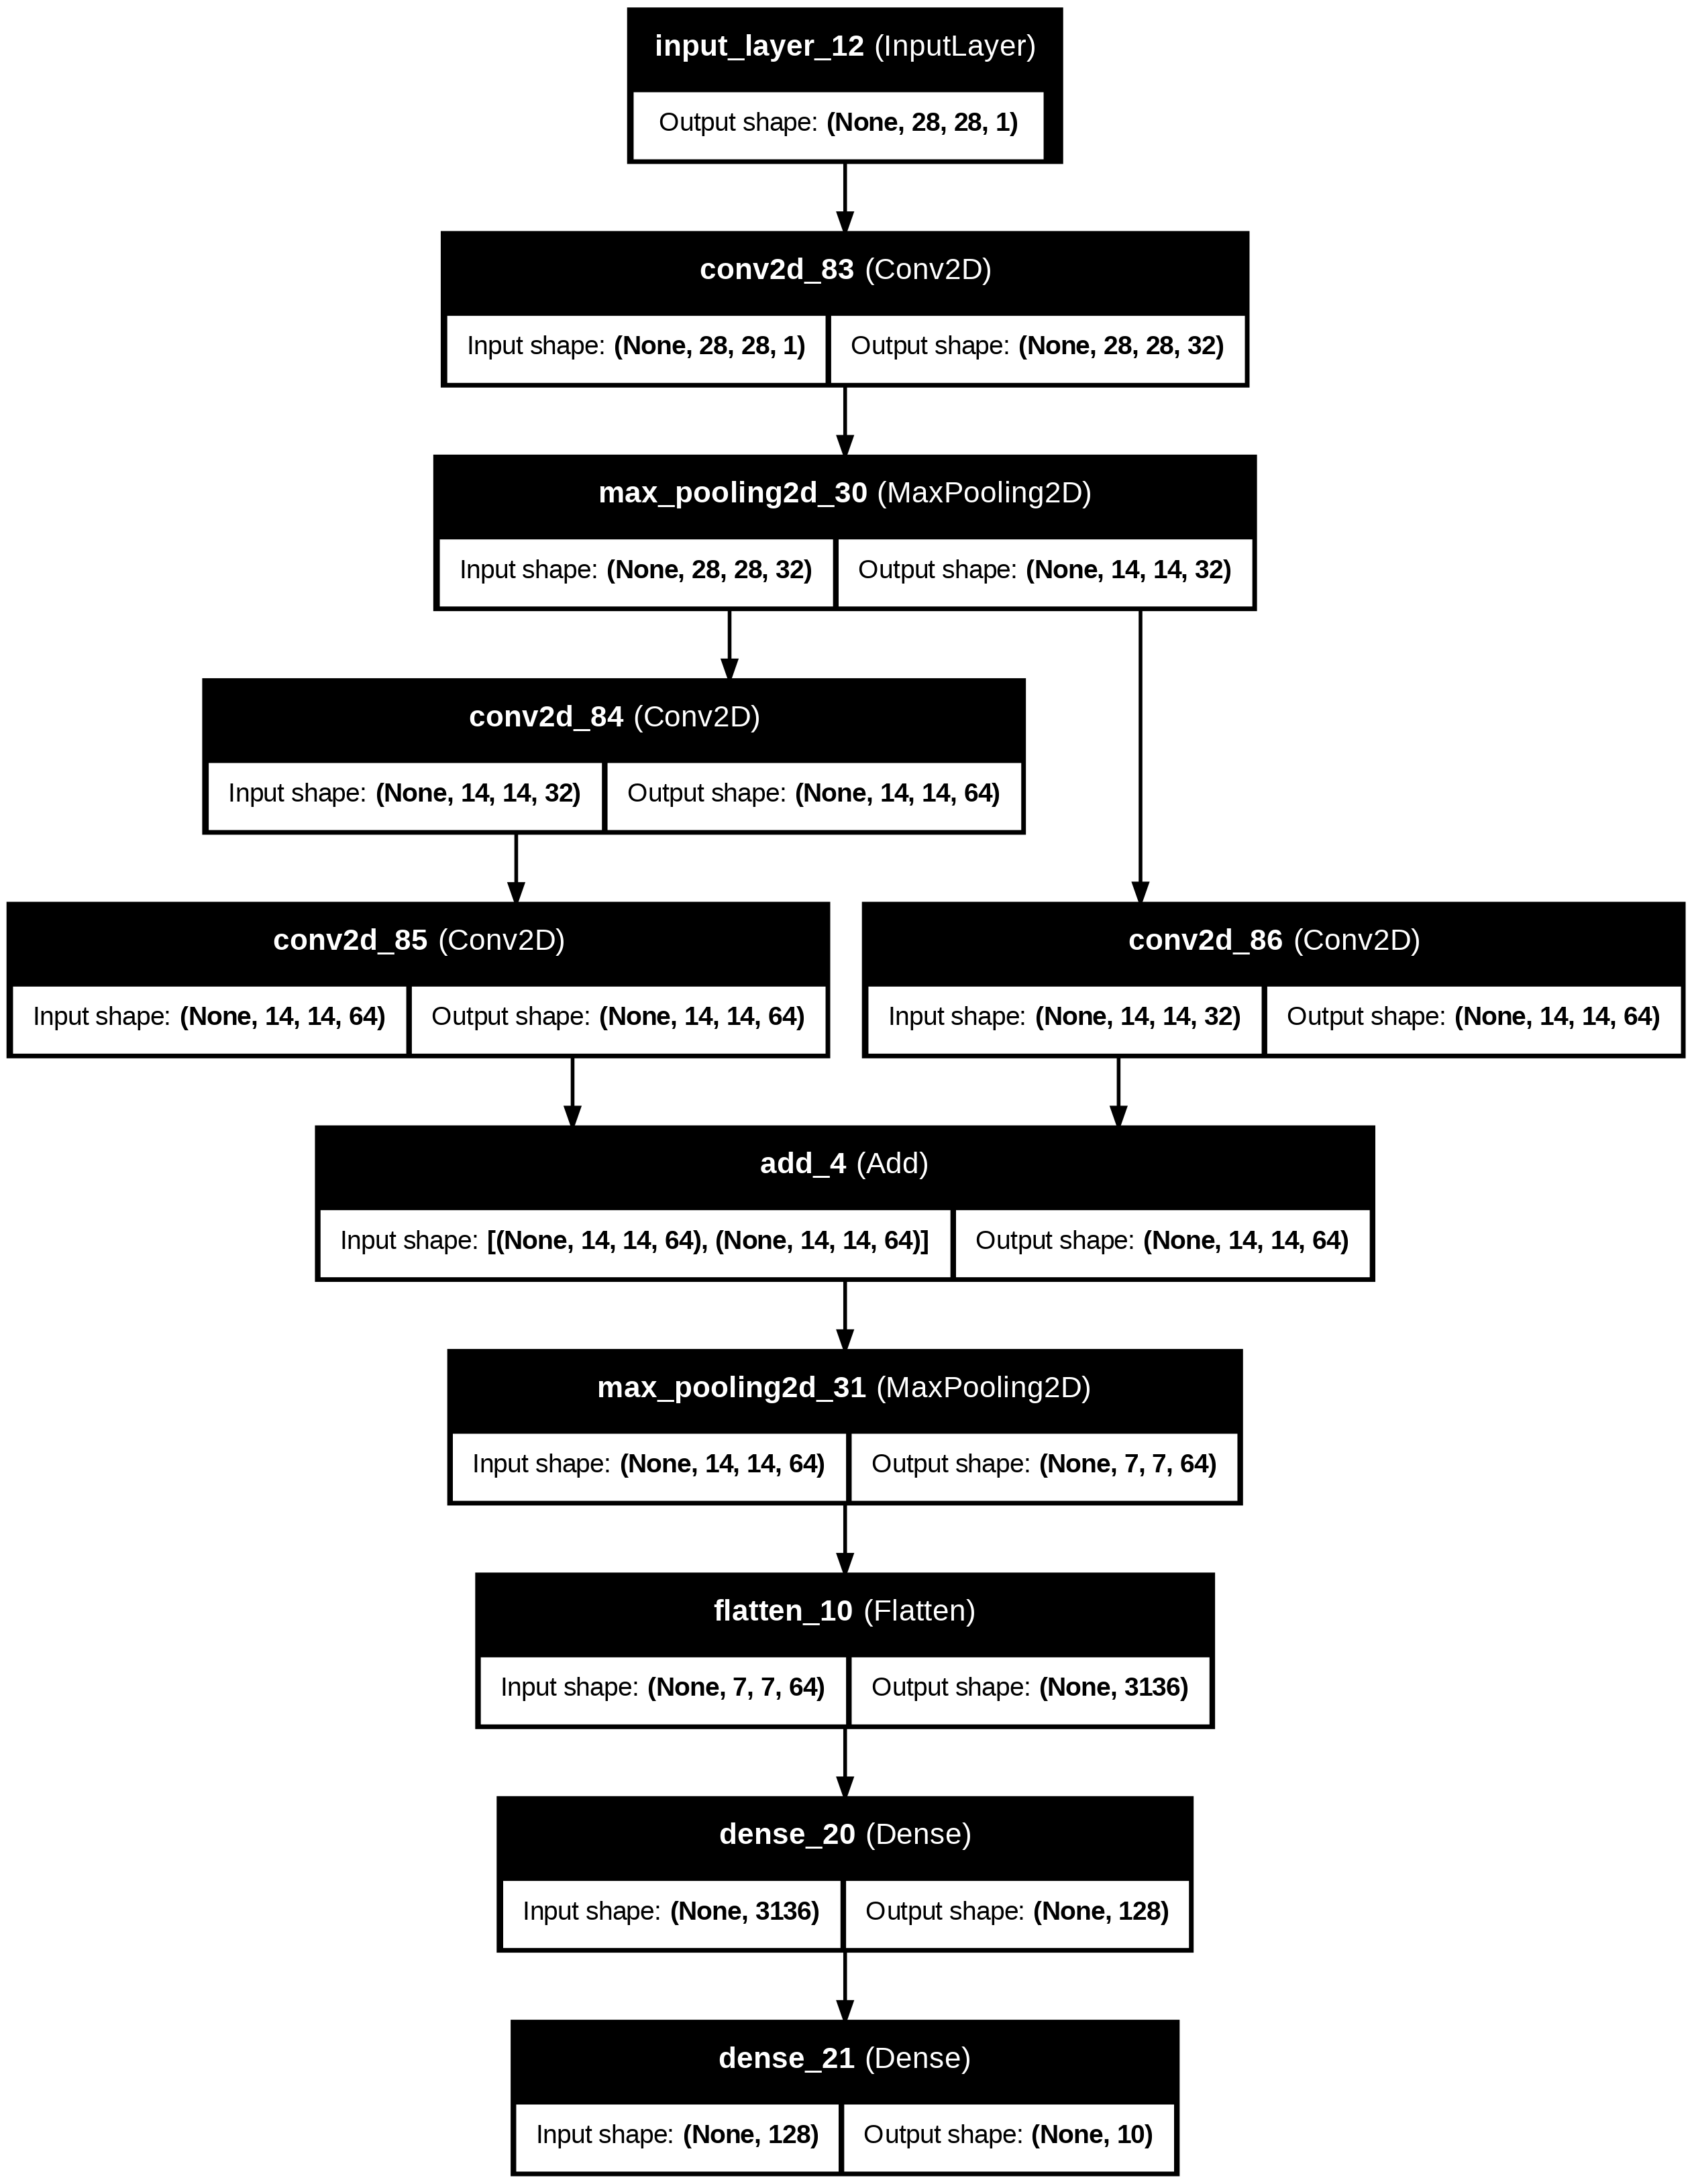

In [24]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  # Adjust the skip connection's channels to match 'net' before adding
  skip_adjusted = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(skip)
  added = Add()([net,skip_adjusted])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

### Disconnected Graph


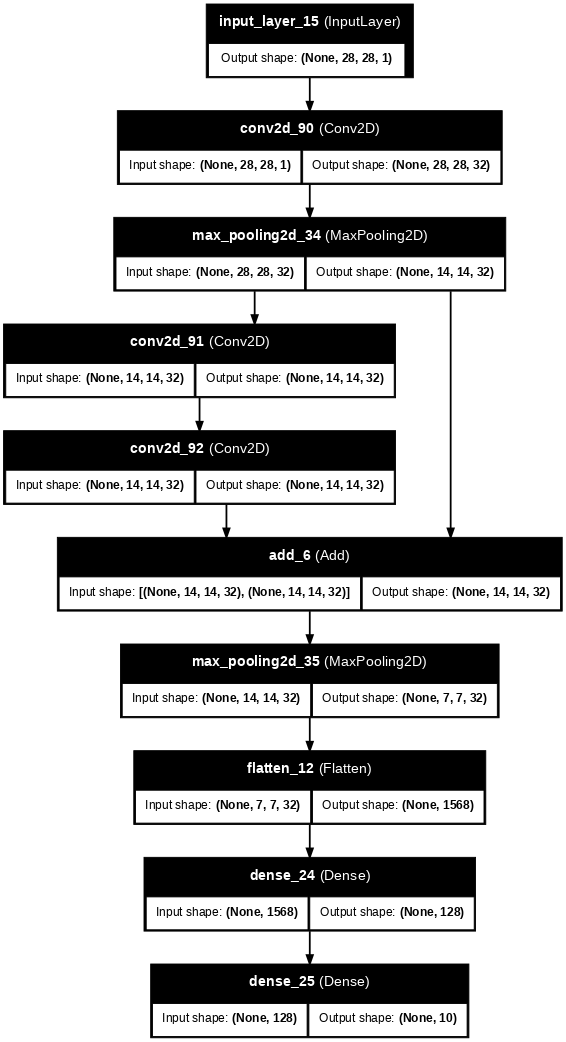

In [26]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)

### Alternate Graph with Intermediate Addition


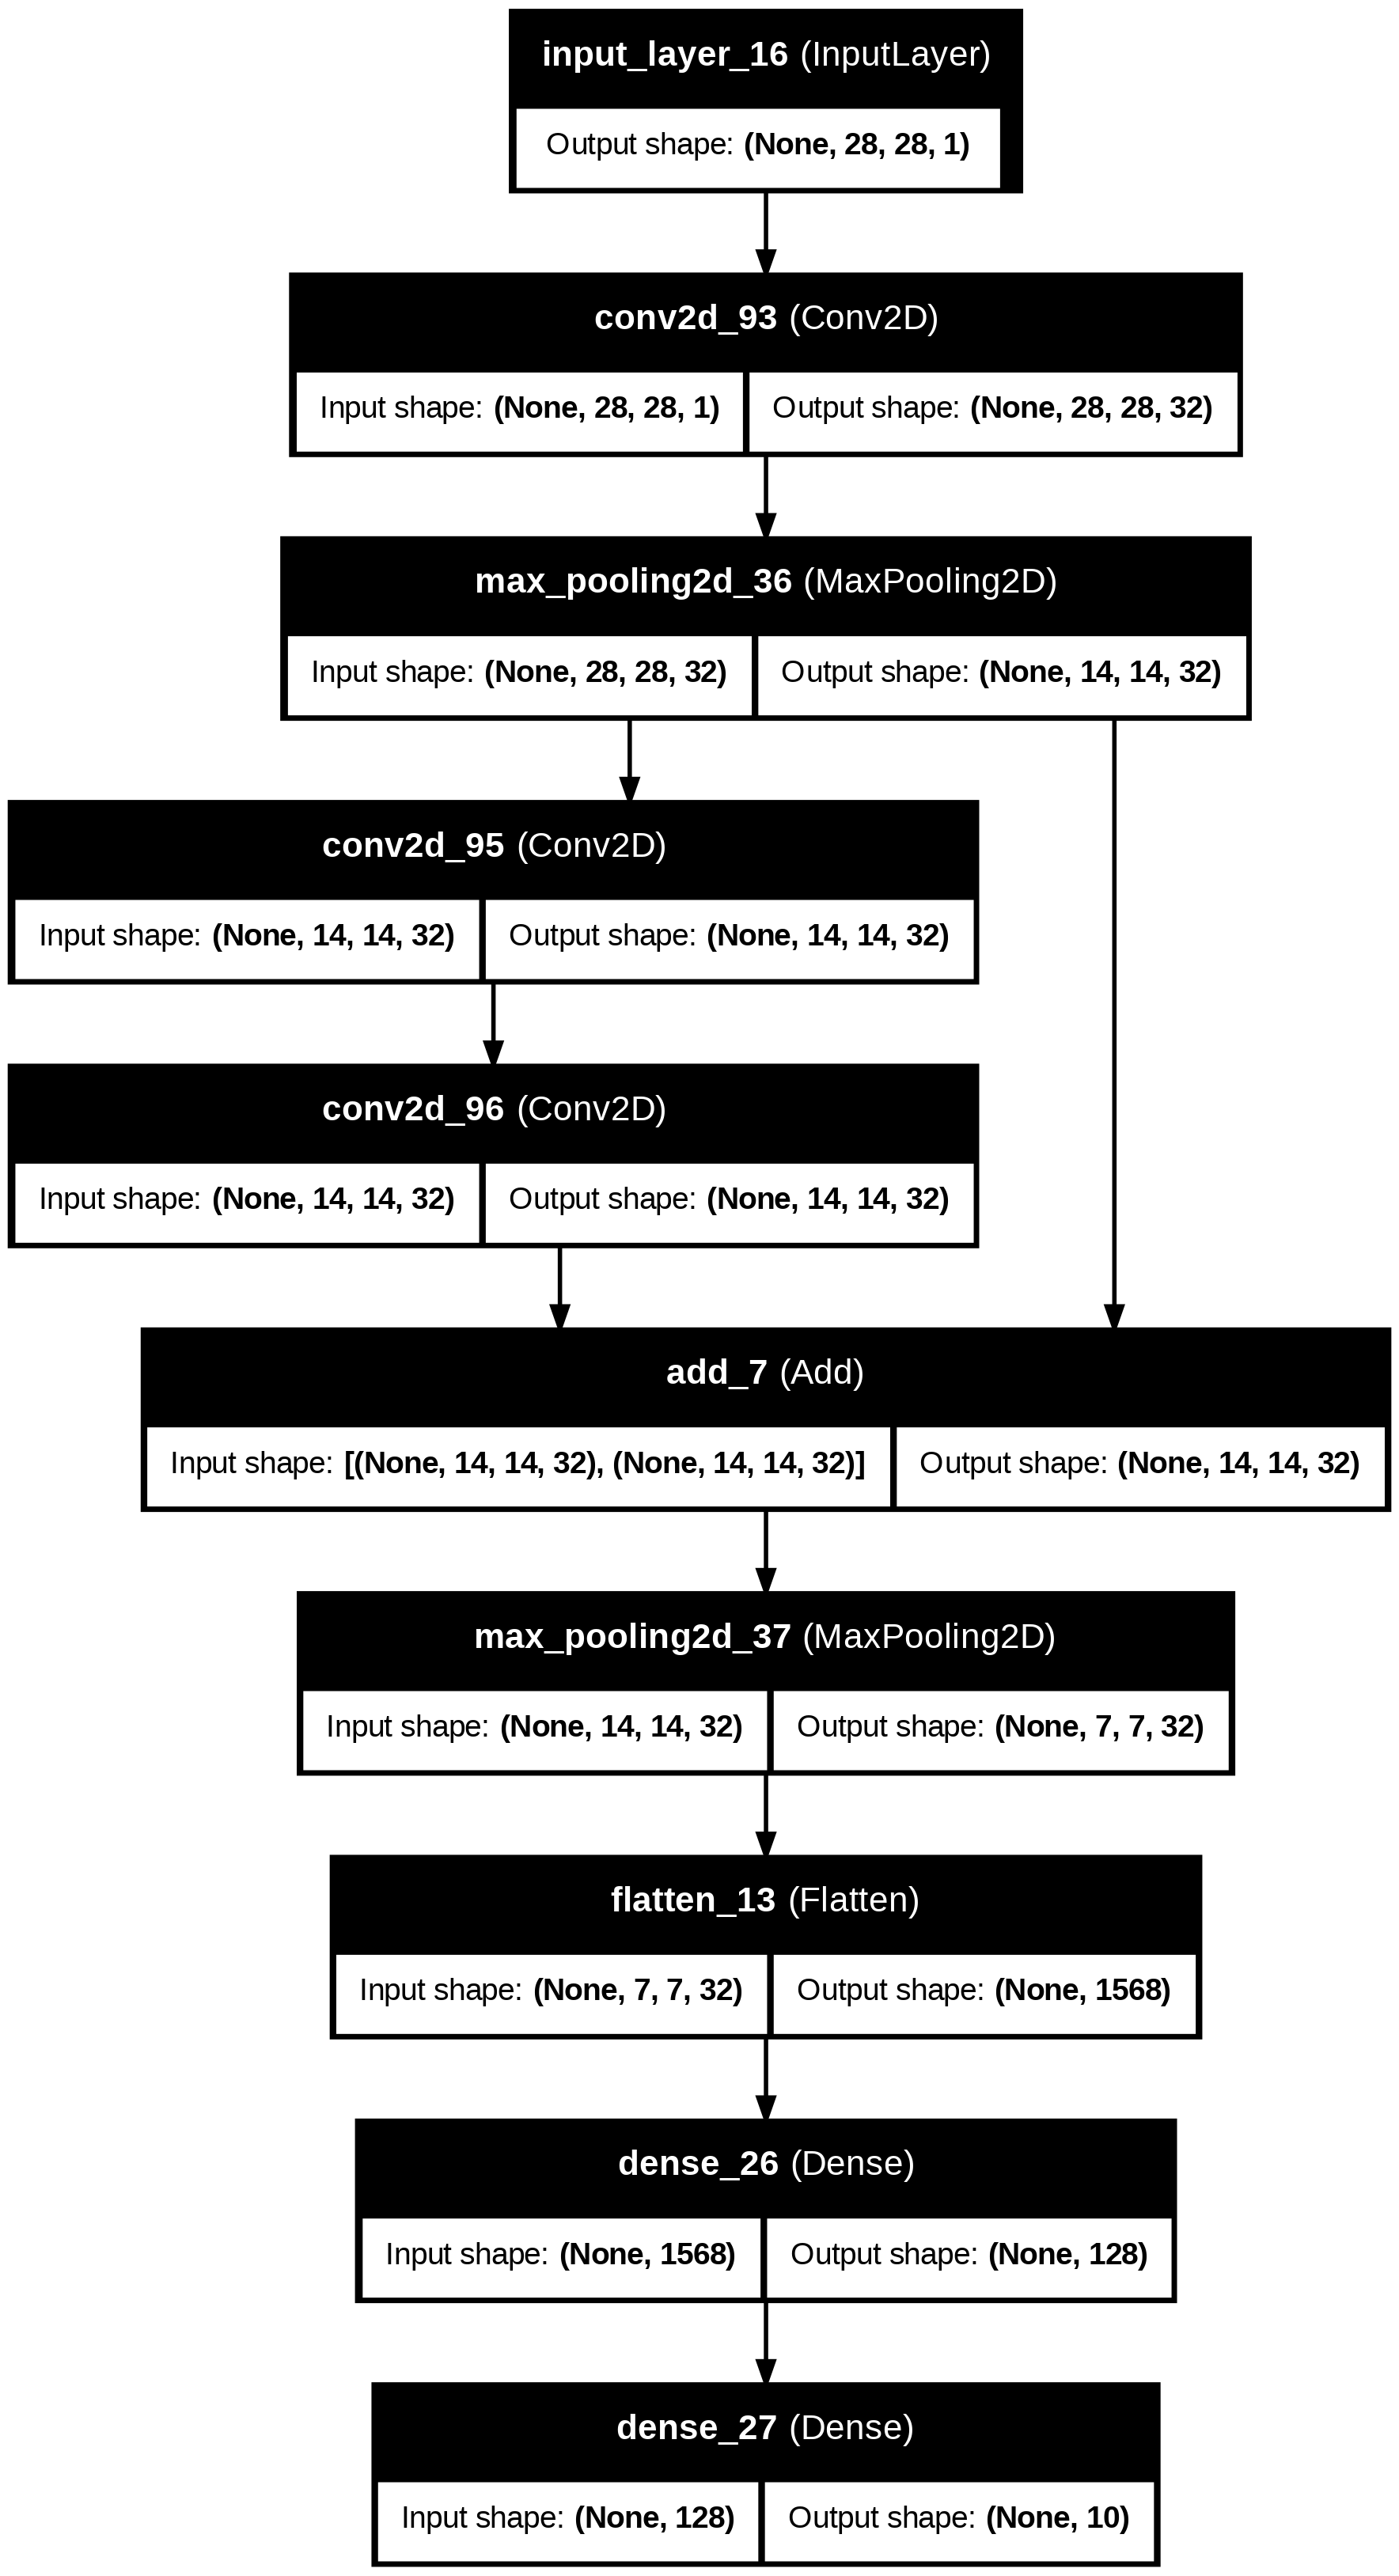

In [27]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  useless = Conv2D(256, kernel_size=(3, 3),activation='relu', padding='same')(net) # This node is not connected to anything
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


### Alternate Disconnected-Input Example


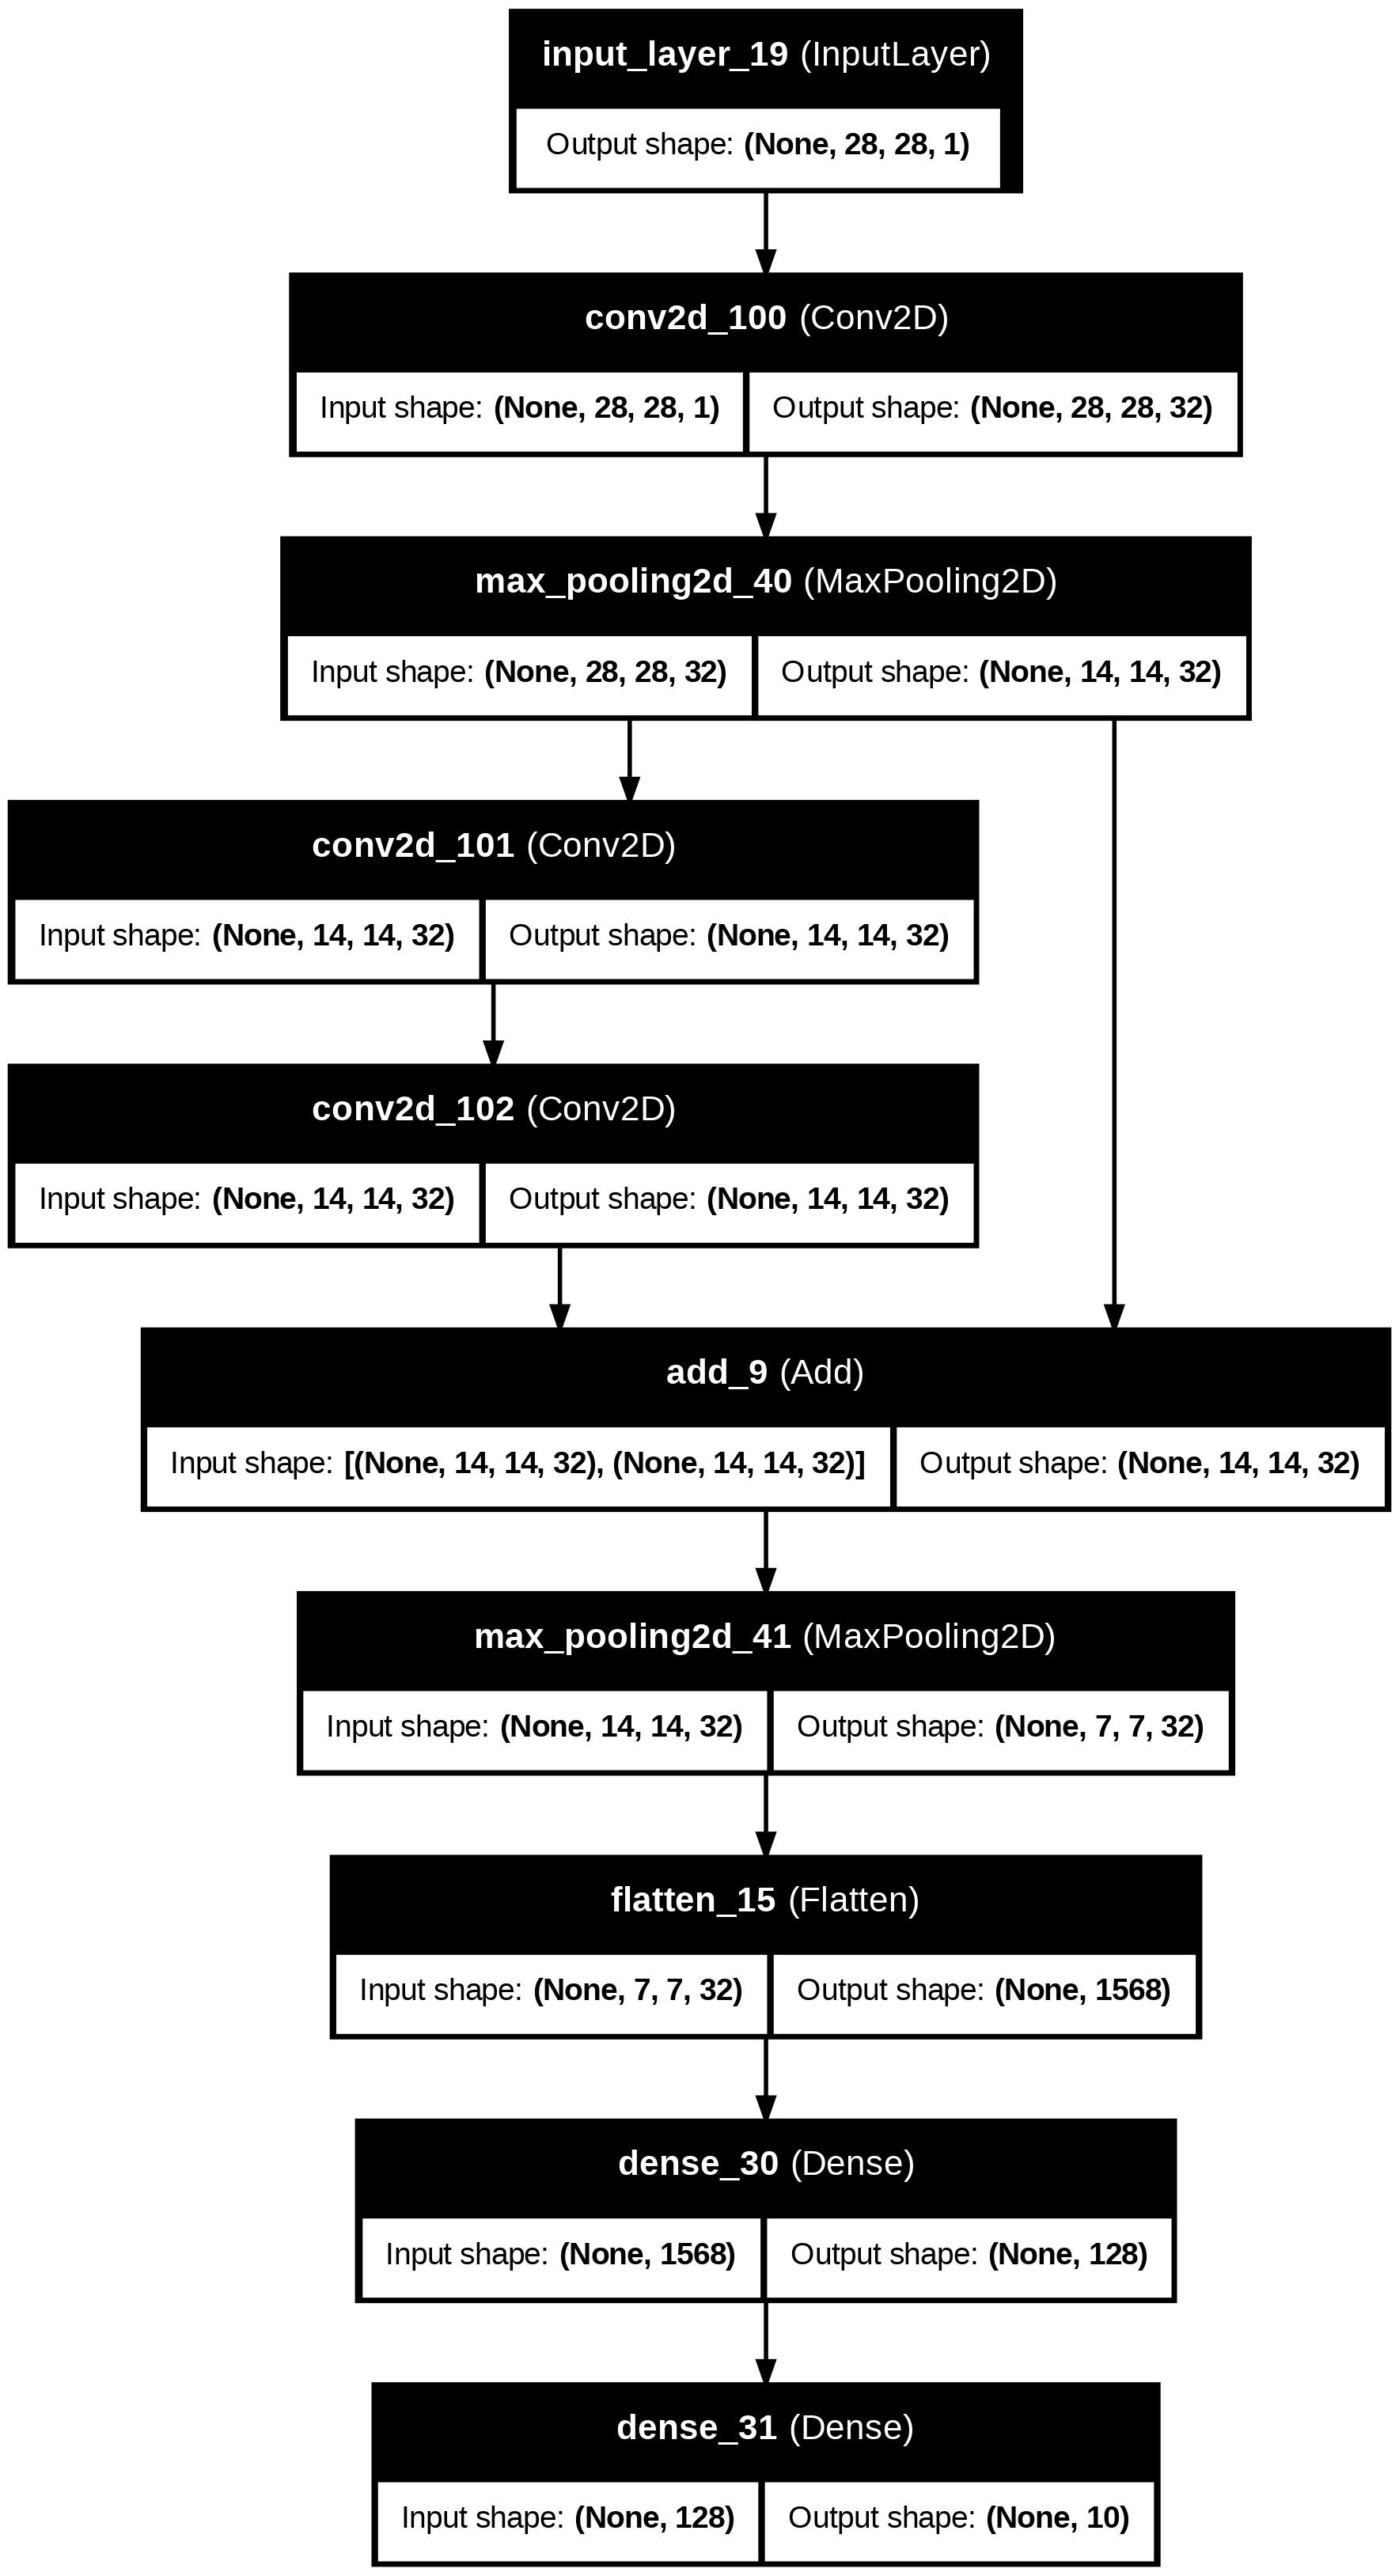

In [29]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

### Additional Parallel-Branch Definition


In [30]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch3)
  concatenated = Concatenate()([branch1,branch2,branch3])
  net = MaxPooling2D(pool_size=(2, 2))(concatenated)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


## Additional Functional API Graph Construction Patterns

The following examples extend the core Functional API concepts with additional tensor-connectivity patterns. They are kept in the same notebook because they deepen the same architectural theme rather than forming a separate portfolio topic.


## Pattern 1: Basic Functional CNN


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │        62,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,050 (246.29 KB)

 Trainable params: 63,050 (246.29 KB)

 Non-trainable params: 0 (0.00 B)

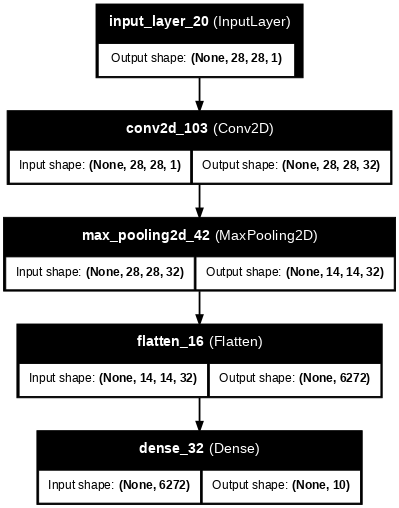

In [31]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Flatten()(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
cnn.summary()
plot_model(cnn, show_shapes=True, show_layer_names=True, dpi=64)


## Pattern 2: Alternate Tensor Path


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

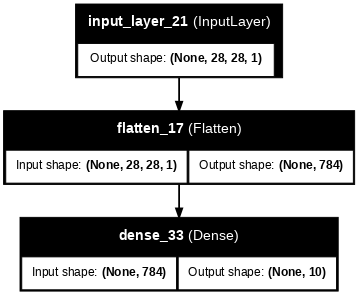

In [32]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Flatten()(inputs)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
cnn.summary()
plot_model(cnn, show_shapes=True, show_layer_names=True, dpi=64)


## Pattern 3: Three-Branch Feature Fusion


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 28, 28,    │         32 │ input_layer_22[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 28, 28,    │      4,640 │ conv2d_105[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 28, 28,    │         32 │ input_layer_22[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 28, 28, 8) │         16 │ input_layer_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 28, 28,    │          0 │ conv2d_106[0][0], │
│ (Concatenate)       │ 56)               │            │ conv2d_107[0][0], │
│                     │                   │            │ conv2d_108[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_44    │ (None, 14, 14,    │          0 │ concatenate_7[0]… │
│ (MaxPooling2D)      │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 10976)     │          0 │ max_pooling2d_44… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 10)        │    109,770 │ flatten_18[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,490 (447.23 KB)

 Trainable params: 114,490 (447.23 KB)

 Non-trainable params: 0 (0.00 B)

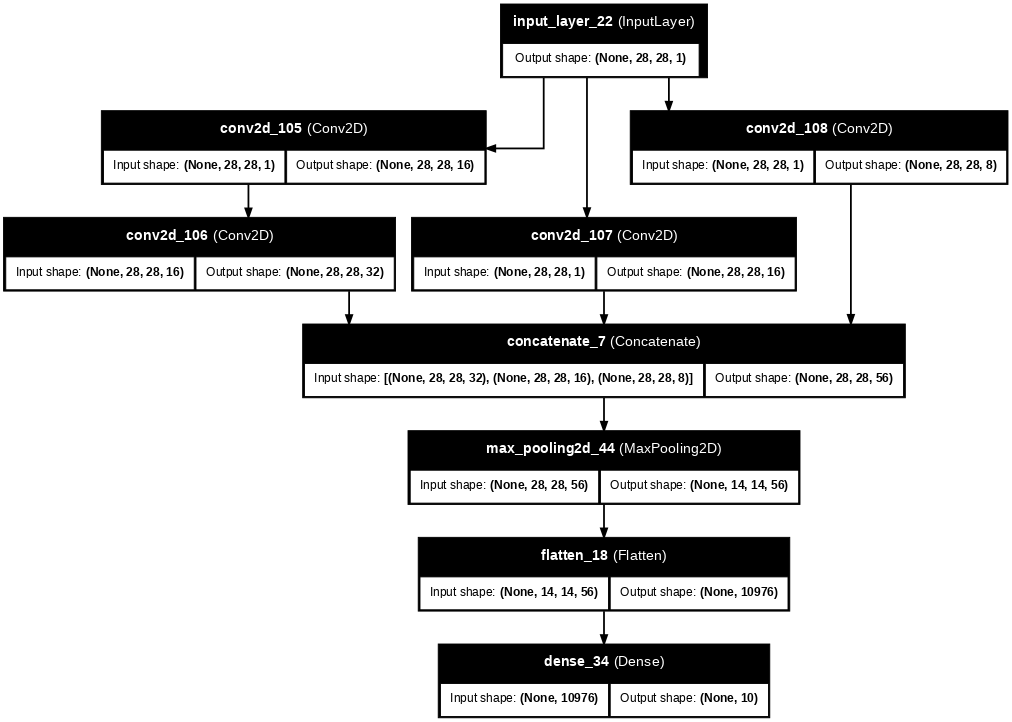

In [33]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(16, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(16, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch4 = Conv2D(8, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  concatenated = Concatenate()([branch1,branch2,branch4])
  concatenated = MaxPooling2D(pool_size=(2, 2))(concatenated)
  net = Flatten()(concatenated)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
cnn.summary()
plot_model(cnn,  show_shapes=True, show_layer_names=True,dpi=64)


## Pattern 4: Residual Addition with Matching Shapes


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 28, 28,    │        320 │ input_layer_23[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_45    │ (None, 14, 14,    │          0 │ conv2d_109[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 14, 14,    │      9,248 │ max_pooling2d_45… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 14, 14,    │      9,248 │ conv2d_110[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 14, 14,    │          0 │ conv2d_111[0][0], │
│                     │ 32)               │            │ max_pooling2d_45… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 7, 7, 32)  │          0 │ add_10[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 1568)      │          0 │ max_pooling2d_46… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 128)       │    200,832 │ flatten_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 10)        │      1,290 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 220,938 (863.04 KB)

 Trainable params: 220,938 (863.04 KB)

 Non-trainable params: 0 (0.00 B)

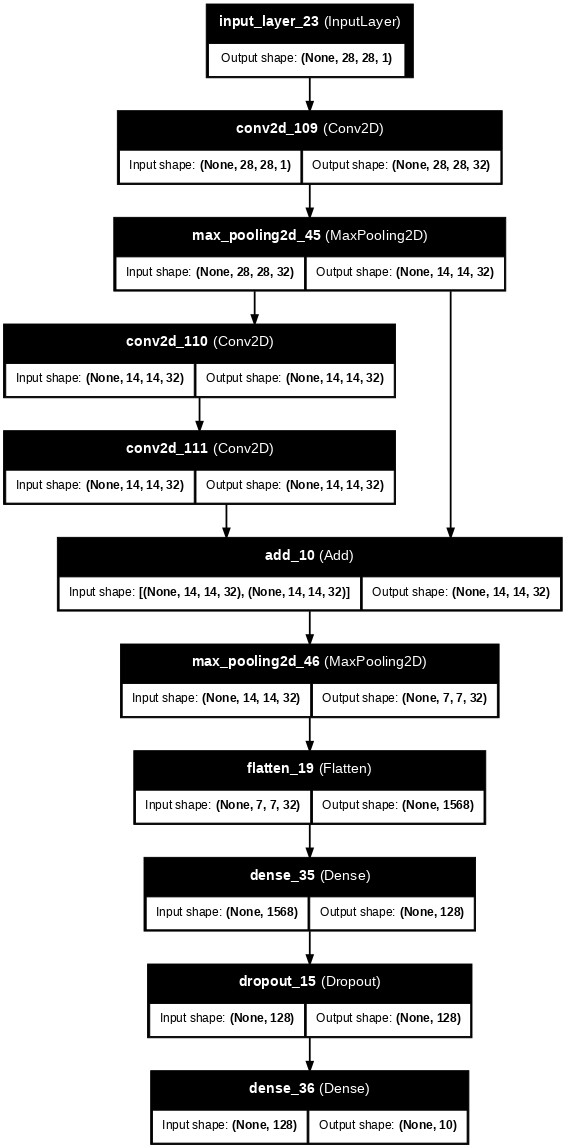

In [34]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
cnn.summary()
plot_model(cnn,   to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


## Pattern 5: Residual Addition with Channel Mismatch


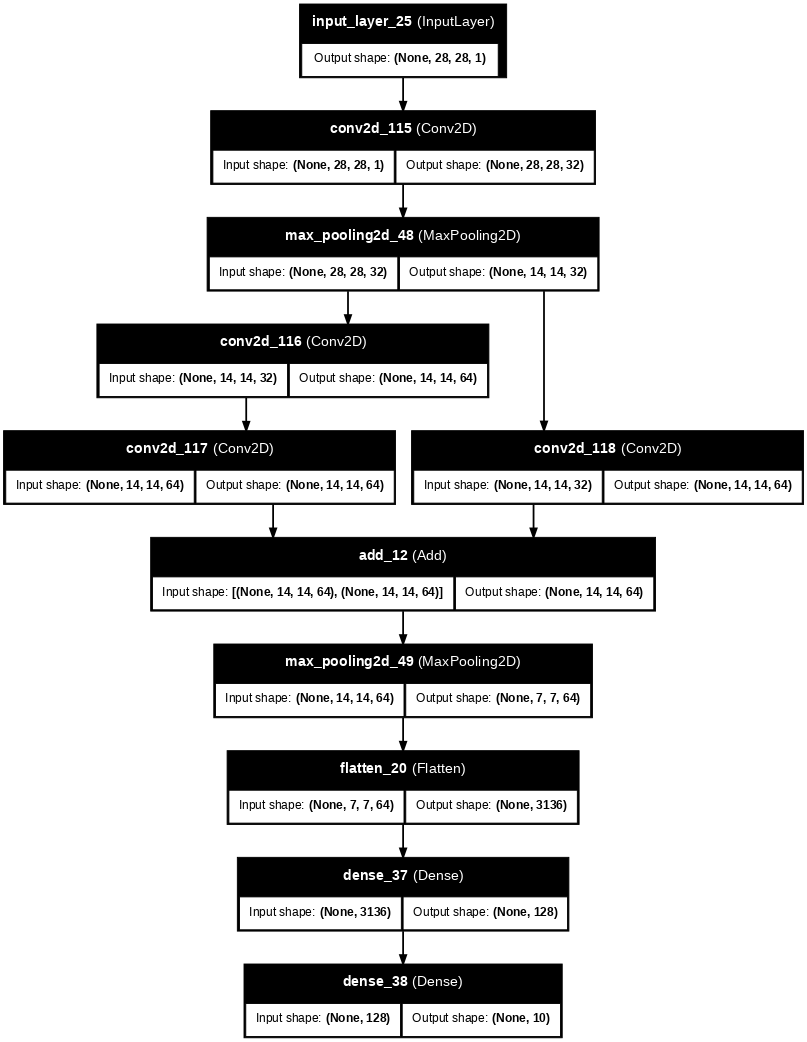

In [36]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  # Adjust the skip connection's channels to match 'net' before adding
  skip_adjusted = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(skip)
  added = Add()([net,skip_adjusted])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)

## Pattern 6: Multiple-Output Functional Graph


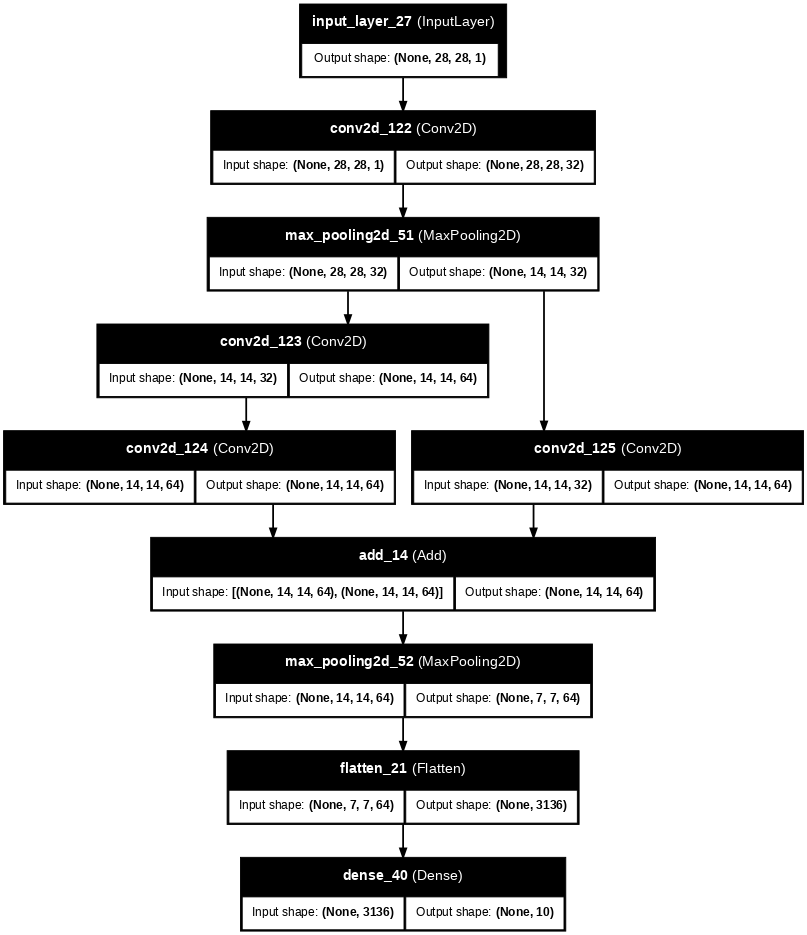

In [38]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  # Adjust the skip connection's channels to match 'net' before adding
  skip_adjusted = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(skip)
  added = Add()([net,skip_adjusted])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  x = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)

## Pattern 7: Additional Multi-Output Structure


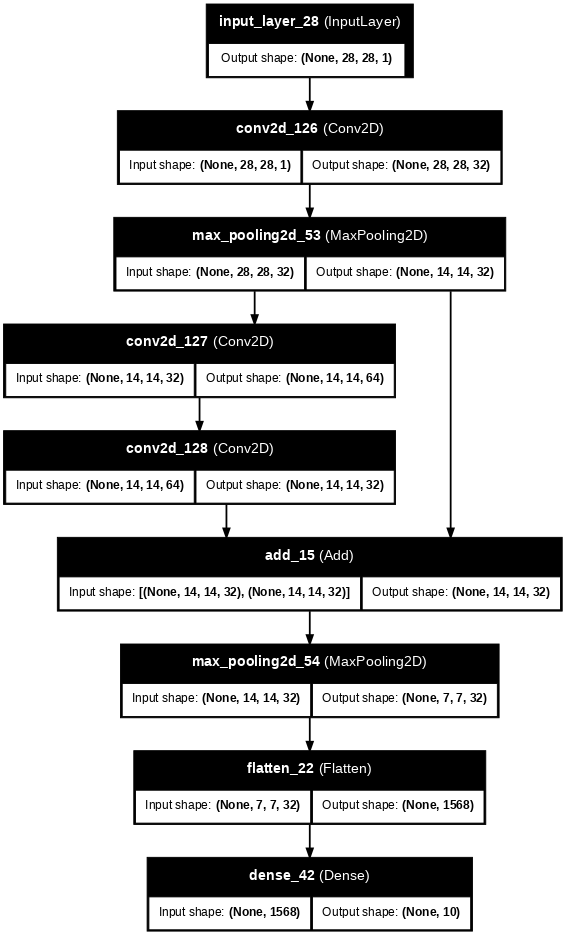

In [39]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  x = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


## Pattern 8: Repeated Residual Combination


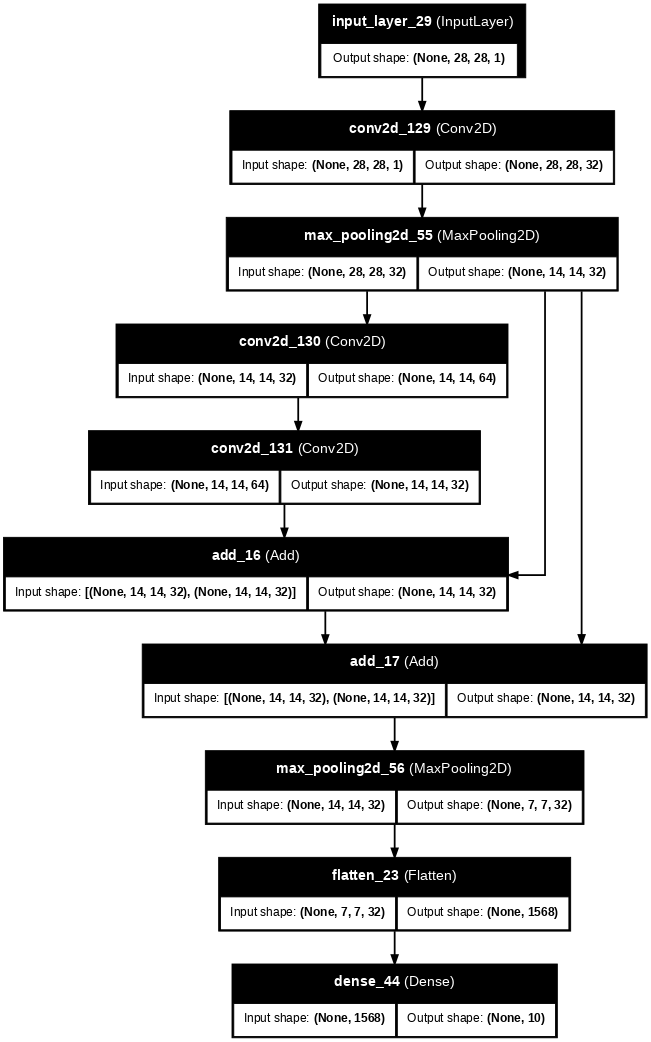

In [40]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  added = Add()([added,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Flatten()(net)
  x = Dense(128, activation='relu')(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

cnn = cnn_model_api()
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True,dpi=64)


## Takeaways

These patterns emphasize that Functional API design is fundamentally about explicitly connecting tensors. Shape compatibility matters for additive shortcuts, while concatenation supports branch fusion even when feature channels differ.


## Final Takeaways

The Keras Functional API generalizes neural-network construction from a single sequential chain to an explicit computation graph. The examples in this notebook cover parallel branches, Inception-style processing, residual and skip connections, multiple outputs, branch fusion, tensor-shape constraints, and graph-connectivity errors.

These concepts provide the architectural foundation for later models such as residual networks, transfer-learning systems, autoencoders, and U-Net-style segmentation networks.
